# 02. Subcellular Model Benchmarking & Ablations

## Overview
This notebook evaluates model architectures, pooling strategies, and loss formulations across the 11-compartment subcellular localization benchmark.

### Models Evaluated:
1. **Random Control (`ctrl`)**: Shuffled-label baseline.
2. **Logistic Regression (`LR`)**: Linear classifier on 1280-dim ESM embeddings.
3. **1-Hidden MLP (`M1`)**: $1280 \to 64 \to \text{ReLU} \to 11$.
4. **2-Hidden MLP (`M2`)**: $1280 \to 128 \to \text{ReLU} \to 64 \to \text{ReLU} \to 11$.

### Ablations:
- **Loss Variants**: Standard BCE, Class-weighted BCE ($\ddagger$), Focal Loss ($\bigstar$).
- **Regularization**: Ridge Frobenius penalty $\lambda=10^{-4}$ ($\dagger$).
- **Pooling**: Mean vs. Max sequence pooling.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

import protein_loc as pl

%matplotlib inline
pl.set_seed(42)

## 1. Load Data

In [2]:
train_df_mean, X_mean, y_train = pl.load_subcellular_data('../data/df_train_loc_mean.csv')
train_df_max, X_max, _ = pl.load_subcellular_data('../data/df_train_loc_max.csv')

print(f"Loaded {len(train_df_mean):,} samples with partitions: {train_df_mean['Partition'].unique().tolist()}")

Loaded 11,052 samples with partitions: [2, 1]


## 2. Run Cross-Validation Across Models & Formulations

We evaluate each model using leave-one-homology-partition-out cross-validation.

In [3]:
results = {}

# 1. Random Control
print("Evaluating Random Control...")
y_shuffled = np.random.permutation(y_train)
df_shuffled = train_df_mean.copy()
for i, loc in enumerate(pl.SUBCELLULAR_LOCATIONS):
    df_shuffled[loc] = y_shuffled[:, i]
results['ctrl'] = pl.run_cross_validation(df_shuffled, lambda: pl.LogisticRegression(), epochs=10)

# 2. Logistic Regression (Standard BCE)
print("Evaluating Logistic Regression (LR)...")
results['LR'] = pl.run_cross_validation(train_df_mean, lambda: pl.LogisticRegression(), epochs=100)

# 3. Logistic Regression (Class-Weighted BCE ‡)
print("Evaluating Logistic Regression (LR‡)...")
results['LR‡'] = pl.run_cross_validation(
    train_df_mean, lambda: pl.LogisticRegression(), epochs=100,
    criterion_factory=lambda w: pl.weighted_bce(w)
)

# 4. Logistic Regression (Focal Loss ★)
print("Evaluating Logistic Regression (LR★)...")
results['LR★'] = pl.run_cross_validation(
    train_df_mean, lambda: pl.LogisticRegression(), epochs=100,
    criterion_factory=lambda _: pl.focal_loss
)

# 5. 1-Hidden MLP (M1)
print("Evaluating 1-Hidden MLP (M1)...")
results['M1'] = pl.run_cross_validation(train_df_mean, lambda: pl.get_model('mlp_1h'), epochs=100)

# 6. 1-Hidden MLP (Class-Weighted M1‡)
print("Evaluating 1-Hidden MLP (M1‡)...")
results['M1‡'] = pl.run_cross_validation(
    train_df_mean, lambda: pl.get_model('mlp_1h'), epochs=100,
    criterion_factory=lambda w: pl.weighted_bce(w)
)

# 7. 1-Hidden MLP (Focal Loss M1★)
print("Evaluating 1-Hidden MLP (M1★)...")
results['M1★'] = pl.run_cross_validation(
    train_df_mean, lambda: pl.get_model('mlp_1h'), epochs=100,
    criterion_factory=lambda _: pl.focal_loss
)

# 8. 1-Hidden MLP + Ridge Regularization (M1†)
print("Evaluating 1-Hidden MLP + Ridge (M1†)...")
results['M1†'] = pl.run_cross_validation(
    train_df_mean, lambda: pl.get_model('mlp_1h'), epochs=100,
    regularizer=pl.ridge_penalty(1e-4)
)

# 9. 2-Hidden MLP (M2)
print("Evaluating 2-Hidden MLP (M2)...")
results['M2'] = pl.run_cross_validation(train_df_mean, lambda: pl.get_model('mlp_2h'), epochs=100)

# 10. 2-Hidden MLP + Ridge Regularization (M2†)
print("Evaluating 2-Hidden MLP + Ridge (M2†)...")
results['M2†'] = pl.run_cross_validation(
    train_df_mean, lambda: pl.get_model('mlp_2h'), epochs=100,
    regularizer=pl.ridge_penalty(1e-4)
)

print("\nCross-validation benchmarks completed successfully!")

Evaluating Random Control...
Evaluating Logistic Regression (LR)...
Evaluating Logistic Regression (LR‡)...
Evaluating Logistic Regression (LR★)...
Evaluating 1-Hidden MLP (M1)...
Evaluating 1-Hidden MLP (M1‡)...
Evaluating 1-Hidden MLP (M1★)...
Evaluating 1-Hidden MLP + Ridge (M1†)...
Evaluating 2-Hidden MLP (M2)...
Evaluating 2-Hidden MLP + Ridge (M2†)...

Cross-validation benchmarks completed successfully!


## 2.5. SMOTE Comparison Experiments

We repeat the best-performing 2-hidden-layer MLP architecture with ridge regularization under three oversampling strategies:
- plain per-label SMOTE,
- union SMOTE,
- thresholded label-propagation SMOTE.

Each run follows the same leave-one-partition-out protocol as the rest of the notebook. We are careful to avoid adding synthetic SMOTE samples to the hold-out partition and do not compute the co-occurence matrix from the hold-out as well.


In [4]:
def fold_co_occurrence(y):
    positive_counts = y.sum(axis=0)
    return np.divide(
        y.T @ y,
        positive_counts[:, None],
        out=np.zeros((y.shape[1], y.shape[1]), dtype=float),
        where=positive_counts[:, None] != 0,
    )


smote_augmenters = {
    'SMOTE-PerLabel': lambda X, y: pl.smote_per_label(
        X,
        y,
        target_count=int(y.sum(axis=0).max()),
    ),
    'SMOTE-Union': lambda X, y: pl.smote_union(
        X,
        y,
        target_count=int(y.sum(axis=0).max()),
    ),
    'SMOTE-ThresholdedPropagation': lambda X, y: pl.smote_thresholded_label_propagation(
        X,
        y,
        co_occurrence=fold_co_occurrence(y),
        threshold=0.5,
        target_count=int(y.sum(axis=0).max()),
    ),
}

smote_results = {}
for name, augmenter in smote_augmenters.items():
    print(f'Evaluating {name}...')
    smote_results[name] = pl.run_cross_validation(
        train_df_mean,
        lambda: pl.get_model('mlp_2h'),
        epochs=100,
        regularizer=pl.ridge_penalty(1e-4),
        train_augmentation=augmenter,
    )
    results[name] = smote_results[name]

print('SMOTE comparison experiments completed successfully.')

Evaluating SMOTE-PerLabel...
Evaluating SMOTE-Union...
Evaluating SMOTE-ThresholdedPropagation...
SMOTE comparison experiments completed successfully.


## 3. Comparative Benchmark Summary Table

In [5]:
summary_rows = []
for name, res in results.items():
    m = res['mean']
    s = res['std']
    summary_rows.append({
        'Model': name,
        'Exact Match': f"{m['exact_match']*100:.1f} ± {s['exact_match']*100:.1f}%",
        'Jaccard': f"{m['jaccard']:.3f} ± {s['jaccard']:.3f}",
        'Micro-F1': f"{m['micro_f1']:.3f} ± {s['micro_f1']:.3f}",
        'Macro-F1': f"{m['macro_f1']:.3f} ± {s['macro_f1']:.3f}",
        'Mean MCC': f"{m['mean_mcc']:.3f} ± {s['mean_mcc']:.3f}",
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,Model,Exact Match,Jaccard,Micro-F1,Macro-F1,Mean MCC
0,ctrl,1.4 ± 0.3%,0.150 ± 0.020,0.228 ± 0.021,0.171 ± 0.030,0.004 ± 0.003
1,LR,45.0 ± 1.2%,0.641 ± 0.003,0.708 ± 0.002,0.580 ± 0.014,0.533 ± 0.014
2,LR‡,45.0 ± 1.2%,0.641 ± 0.003,0.708 ± 0.002,0.580 ± 0.014,0.533 ± 0.014
3,LR★,44.3 ± 1.9%,0.635 ± 0.012,0.698 ± 0.006,0.596 ± 0.004,0.544 ± 0.004
4,M1,44.9 ± 1.0%,0.635 ± 0.003,0.697 ± 0.001,0.590 ± 0.006,0.538 ± 0.001
5,M1‡,44.5 ± 1.4%,0.640 ± 0.002,0.703 ± 0.004,0.589 ± 0.005,0.538 ± 0.003
6,M1★,42.9 ± 1.7%,0.618 ± 0.018,0.685 ± 0.010,0.585 ± 0.000,0.529 ± 0.003
7,M1†,46.1 ± 1.0%,0.644 ± 0.009,0.708 ± 0.002,0.575 ± 0.021,0.528 ± 0.022
8,M2,42.4 ± 1.7%,0.616 ± 0.016,0.676 ± 0.010,0.562 ± 0.008,0.503 ± 0.012
9,M2†,46.3 ± 1.2%,0.641 ± 0.008,0.701 ± 0.004,0.586 ± 0.012,0.537 ± 0.019


## 4. Per-Class MCC Heatmap Matrix

We visualize the cross-validated per-compartment MCC across all models.

findfont: Failed to find font weight medium, now using 400.


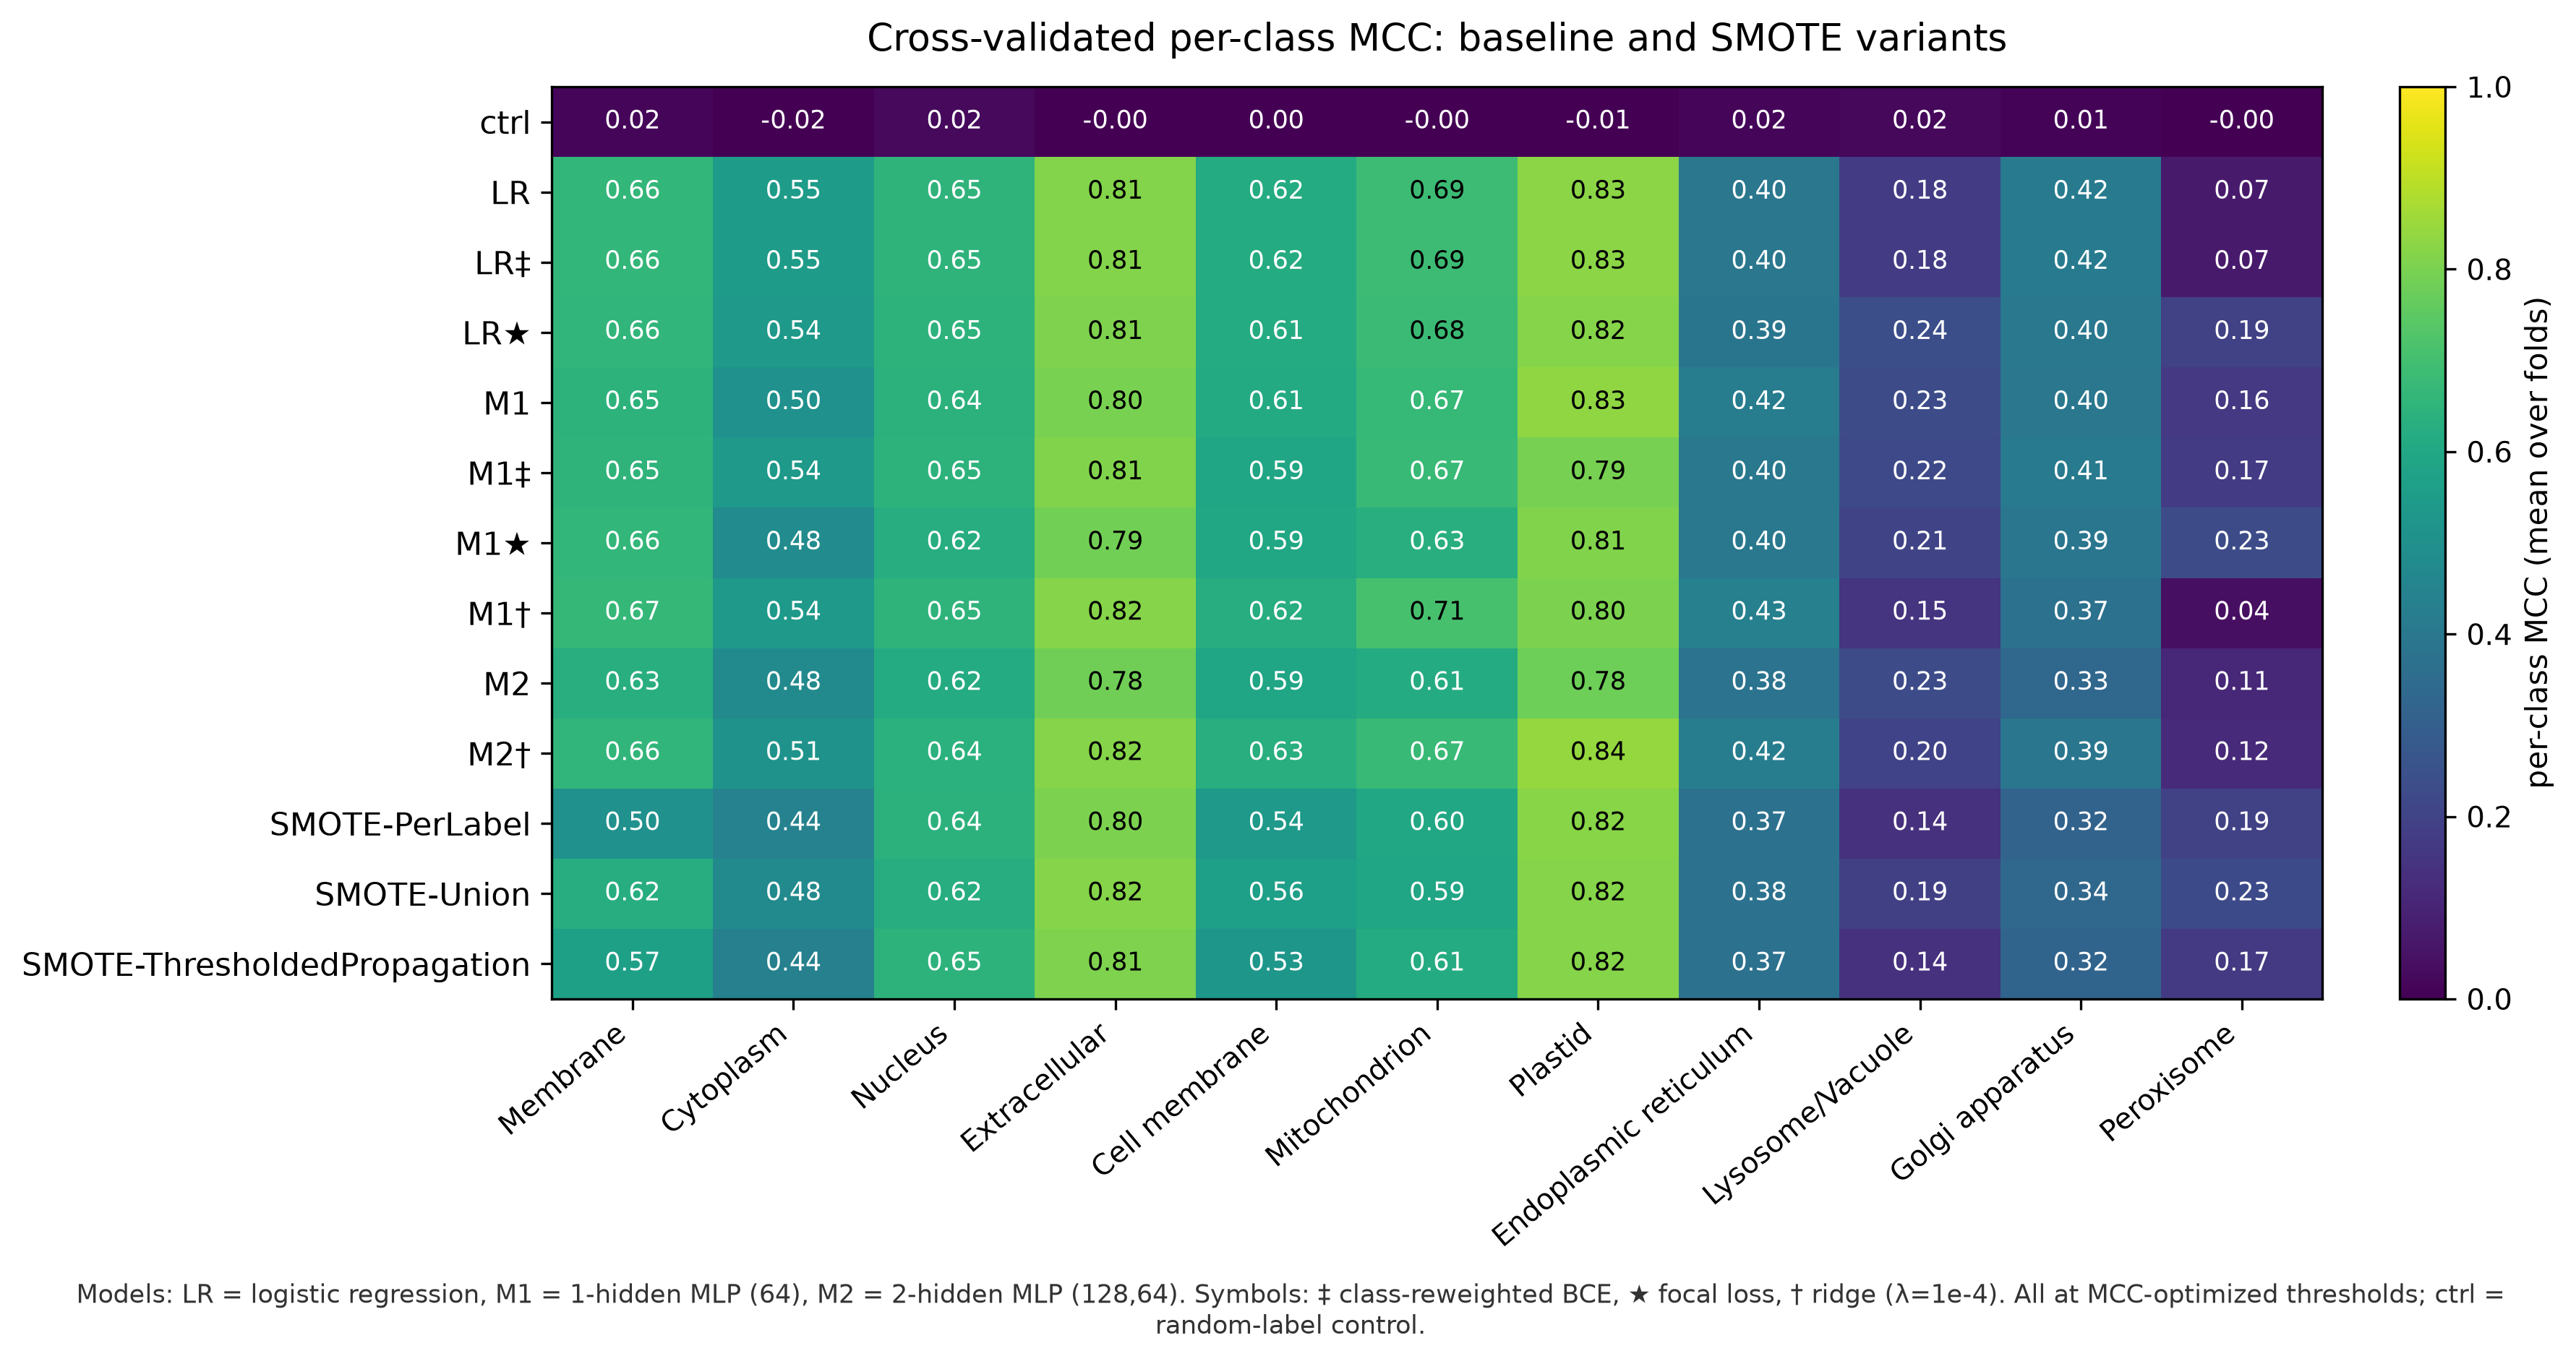

In [6]:
model_order = [
    'ctrl',
    'LR',
    'LR‡',
    'LR★',
    'M1',
    'M1‡',
    'M1★',
    'M1†',
    'M2',
    'M2†',
    'SMOTE-PerLabel',
    'SMOTE-Union',
    'SMOTE-ThresholdedPropagation',
]

mcc_matrix = pd.DataFrame(
    {
        loc: [results[model]['per_class_mcc_mean'][loc] for model in model_order]
        for loc in pl.SUBCELLULAR_LOCATIONS
    },
    index=model_order,
)

fig, ax = pl.plot_cross_validated_mcc_heatmap(
    mcc_data=mcc_matrix,
    title='Cross-validated per-class MCC: baseline and SMOTE variants',
    save_path='../figures/cross_validated_mcc_heatmap_smote.pdf',
)
plt.show()